In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:



from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
df = pd.DataFrame(data.data , columns = data.feature_names)
df['target' ]  = data.target

In [ ]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
df.shape

(569, 31)

In [ ]:
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df['target'].value_counts()

,count
target,
1,357
0,212


In [ ]:
X = df.drop(['target'] , axis = 1)
y = df['target']

In [ ]:
print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [ ]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(455, 30)
(114, 30)
(455,)
(114,)


In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [ ]:
print("scaling done.")

scaling done.


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
model = keras.Sequential([
    layers.Dense(32 , activation = 'relu' , input_shape = (X_train_scaled.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(16 , activation = 'relu'),
    layers.Dropout(0.2),
    layers.Dense(1 , activation = 'sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')]
)

In [ ]:
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.4918 - loss: 0.7726 - precision: 0.7216 - recall: 0.3070 - val_accuracy: 0.7802 - val_loss: 0.5711 - val_precision: 0.9750 - val_recall: 0.6724
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7610 - loss: 0.5183 - precision: 0.8811 - recall: 0.7149 - val_accuracy: 0.9011 - val_loss: 0.3959 - val_precision: 0.9455 - val_recall: 0.8966
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8434 - loss: 0.3999 - precision: 0.9212 - recall: 0.8202 - val_accuracy: 0.9451 - val_loss: 0.2868 - val_precision: 0.9492 - val_recall: 0.9655
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9286 - loss: 0.2738 - precision: 0.9550 - recall: 0.9298 - val_accuracy: 0.9451 - val_loss: 0.2172 - val_precision: 0.9492 - val_recall: 0.9655
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9258 - loss: 0.2297 - precision: 0.9389 - recall: 0.9430 - val_accuracy: 0.9670 - val_loss: 0.1755 - 

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_proba = model.predict(X_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int)

print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        43
           1       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Confusion Matrix:
[[42  1]
 [ 1 70]]


In [ ]:
model.save("breast_cancer_model.h5")

import joblib
joblib.dump(sc, "breast_cancer_scaler.pkl")

['breast_cancer_scaler.pkl']

In [ ]:
def predict_from_index(row_index):
    sample = X.iloc[row_index].values.reshape(1, -1)
    actual_label = "Benign" if y.iloc[row_index] == 1 else "Malignant"

    sample_scaled = sc.transform(sample)
    prediction_proba = model.predict(sample_scaled)[0][0]
    prediction = "Benign (Non-Cancerous)" if prediction_proba > 0.5 else "Malignant (Cancerous)"
    confidence = prediction_proba if prediction_proba > 0.5 else 1 - prediction_proba

    print(f"Sample #{row_index}")
    print(f"Actual Label: {actual_label}")
    print(f"Model Prediction: {prediction}")
    print(f"Confidence: {confidence*100:.1f}%")

# Test kar
predict_from_index(38)    # Malignant sample
predict_from_index(523)   # Benign sample

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Sample #38
Actual Label: Malignant
Model Prediction: Malignant (Cancerous)
Confidence: 99.5%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Sample #523
Actual Label: Benign
Model Prediction: Benign (Non-Cancerous)
Confidence: 96.8%


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance.head(6))

worst area              0.153892
worst concave points    0.144663
mean concave points     0.106210
worst radius            0.077987
mean concavity          0.068001
worst perimeter         0.067115
dtype: float64


In [ ]:
import gradio as gr
import numpy as np

top_features = ['worst area', 'worst concave points', 'mean concave points',
                 'worst radius', 'mean concavity', 'worst perimeter']

default_values = X.mean()

def predict_simplified(worst_area, worst_concave_points, mean_concave_points,
                        worst_radius, mean_concavity, worst_perimeter):

    input_row = default_values.copy()

    input_row['worst area'] = worst_area
    input_row['worst concave points'] = worst_concave_points
    input_row['mean concave points'] = mean_concave_points
    input_row['worst radius'] = worst_radius
    input_row['mean concavity'] = mean_concavity
    input_row['worst perimeter'] = worst_perimeter

    input_scaled = sc.transform([input_row.values])
    prediction_proba = model.predict(input_scaled)[0][0]
    prediction = "Benign (Non-Cancerous)" if prediction_proba > 0.5 else "Malignant (Cancerous)"
    confidence = prediction_proba if prediction_proba > 0.5 else 1 - prediction_proba

    return f"Prediction: {prediction}\nConfidence: {confidence*100:.1f}%"

demo = gr.Interface(
    fn=predict_simplified,
    inputs=[
        gr.Number(label="Worst Area", value=float(X['worst area'].mean())),
        gr.Number(label="Worst Concave Points", value=float(X['worst concave points'].mean())),
        gr.Number(label="Mean Concave Points", value=float(X['mean concave points'].mean())),
        gr.Number(label="Worst Radius", value=float(X['worst radius'].mean())),
        gr.Number(label="Mean Concavity", value=float(X['mean concavity'].mean())),
        gr.Number(label="Worst Perimeter", value=float(X['worst perimeter'].mean())),
    ],
    outputs="text",
    title="Breast Cancer Detection (Simplified)",
    description="Enter the 6 most important measurements to predict Malignant vs Benign."
)

demo.launch(inline=True, share=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

In [ ]:
def predict_simplified_direct(worst_area, worst_concave_points, mean_concave_points,
                                worst_radius, mean_concavity, worst_perimeter):

    input_row = X.mean().copy()

    input_row['worst area'] = worst_area
    input_row['worst concave points'] = worst_concave_points
    input_row['mean concave points'] = mean_concave_points
    input_row['worst radius'] = worst_radius
    input_row['mean concavity'] = mean_concavity
    input_row['worst perimeter'] = worst_perimeter

    input_scaled = sc.transform([input_row.values])
    prediction_proba = model.predict(input_scaled)[0][0]
    prediction = "Benign (Non-Cancerous)" if prediction_proba > 0.5 else "Malignant (Cancerous)"
    confidence = prediction_proba if prediction_proba > 0.5 else 1 - prediction_proba

    print(f"Prediction: {prediction}")
    print(f"Confidence: {confidence*100:.1f}%")

# Malignant sample test
predict_simplified_direct(
    worst_area=2019.0,
    worst_concave_points=0.2654,
    mean_concave_points=0.1471,
    worst_radius=25.38,
    mean_concavity=0.3001,
    worst_perimeter=184.60
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Prediction: Malignant (Cancerous)
Confidence: 100.0%


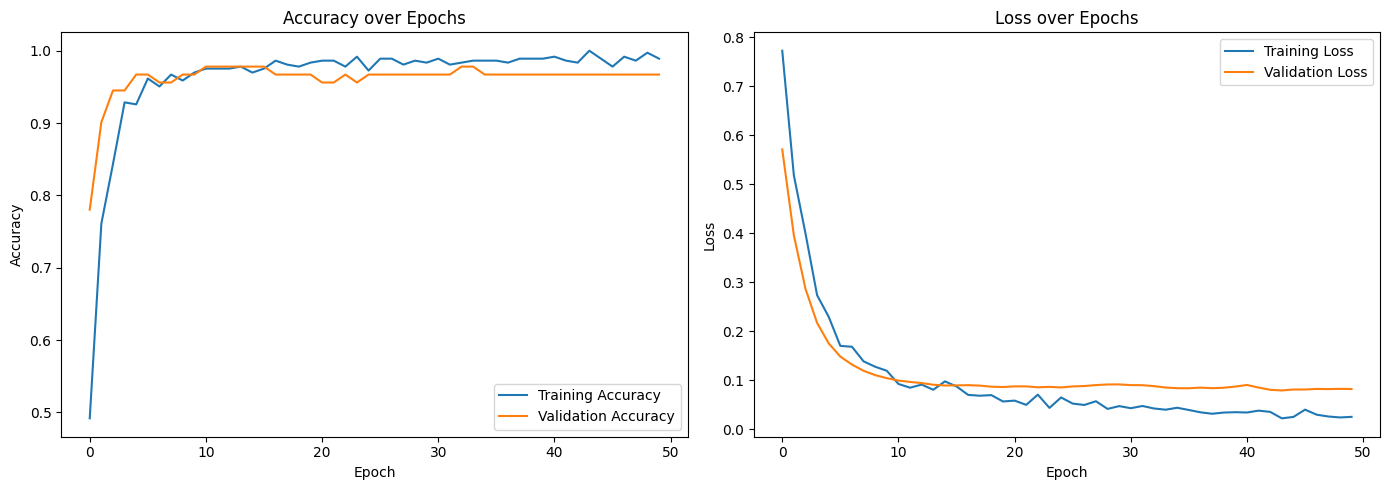

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

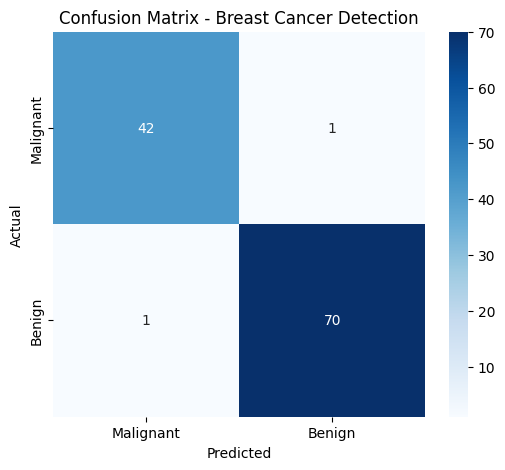

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Breast Cancer Detection')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

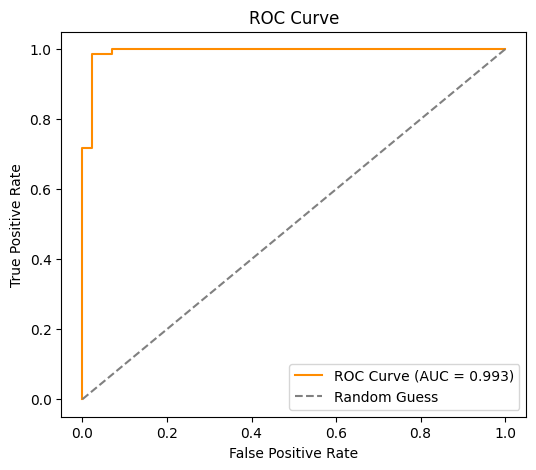

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})', color='darkorange')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

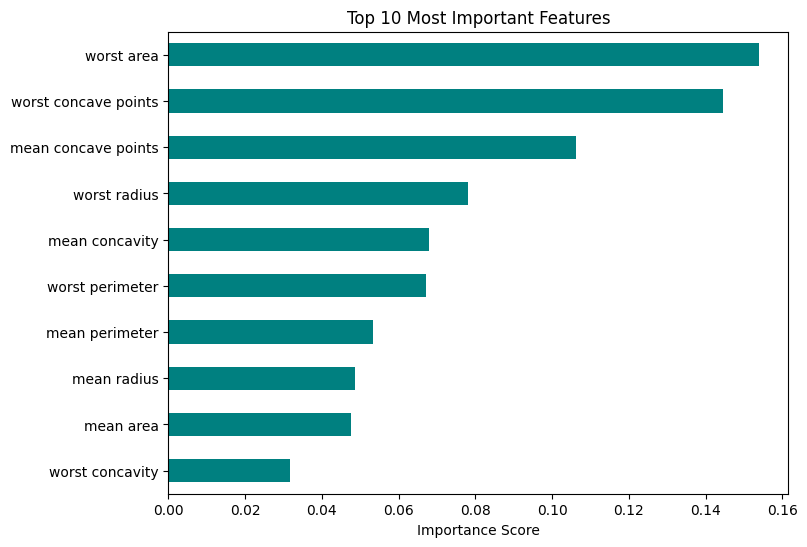

In [ ]:
plt.figure(figsize=(8,6))
importance.head(10).sort_values().plot(kind='barh', color='teal')
plt.xlabel('Importance Score')
plt.title('Top 10 Most Important Features')
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

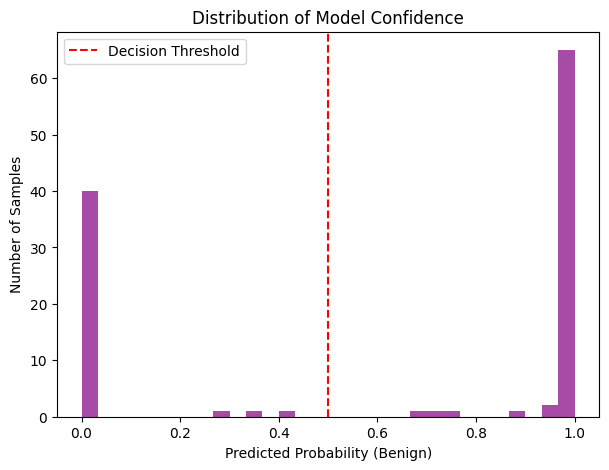

In [ ]:
plt.figure(figsize=(7,5))
plt.hist(y_pred_proba, bins=30, color='purple', alpha=0.7)
plt.axvline(0.5, color='red', linestyle='--', label='Decision Threshold')
plt.xlabel('Predicted Probability (Benign)')
plt.ylabel('Number of Samples')
plt.title('Distribution of Model Confidence')
plt.legend()
plt.savefig('confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import files

# Model aur scaler
files.download("breast_cancer_model.h5")
files.download("breast_cancer_scaler.pkl")

# Graphs
files.download("training_curves.png")
files.download("confusion_matrix.png")

files.download("feature_importance.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model.save("breast_cancer_model.h5")

import joblib
joblib.dump(sc, "breast_cancer_scaler.pkl")

['breast_cancer_scaler.pkl']